==============================================================================
 KAN-Based Deepfake Detection via Phase-Spectrum Analysis
 ─────────────────────────────────────────────────────────
 Dataset  : DeepDetect-2025 (~115 k images — Midjourney, SD3, DALL·E 3)
 Model    : Kolmogorov–Arnold Network (KAN) on flattened phase spectrum
 Target   : Binary classification — Real (0) vs Fake (1)
 Venue    : IEEE journal / conference submission
 Runtime  : Google Colab (≤ 12 GB RAM, T4 / L4 GPU)
==============================================================================

HOW TO USE
----------
Each `# %%` comment starts a new Jupyter cell.
In VS Code → *Run Cell*  |  In Colab → paste each section into a cell.

Key design decisions:
  • NO torchvision.transforms.Resize — resizing destroys high-frequency
    artifacts that are the primary signal for AI-generated image detection.
  • Images are centre-cropped (224×224), converted to grayscale, then the
    2-D FFT is computed and the *phase spectrum* is extracted.
  • The KAN replaces standard linear layers with learnable univariate
    functions on edges (B-spline parameterisation).
  • Memory-safe: images are loaded lazily from disk via PIL — never read
    entirely into RAM.

## CELL 1 — Environment Setup, Installs & Deterministic Seeds

In [ ]:
import subprocess, sys
from contextlib import nullcontext

def _pip(pkg: str) -> None:
    """Install a package silently if not already present."""
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", pkg],
        stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
    )

# Ensure kagglehub is available (Colab may not have it by default)
try:
    import kagglehub
except ImportError:
    _pip("kagglehub")
    import kagglehub

# scikit-learn for metrics
try:
    import sklearn
except ImportError:
    _pip("scikit-learn")

import os, random, time, json, warnings
from pathlib import Path
from typing import List, Tuple, Optional

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as T
from PIL import Image
import matplotlib
import matplotlib.pyplot as plt
# NOTE: We do NOT call matplotlib.use("Agg") so that plt.show() renders
# inline inside Colab / Jupyter notebooks.
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, confusion_matrix,
    ConfusionMatrixDisplay, classification_report,
)
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=UserWarning)

# ── deterministic seeds ──────────────────────────────────────────────────────
SEED = 42

def seed_everything(seed: int = SEED) -> None:
    """Set all random seeds for full reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── CUDA performance knobs for Kaggle T4 ─────────────────────────────────────
if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False
    torch.set_float32_matmul_precision("high")

print(f"Python  : {sys.version.split()[0]}")
print(f"PyTorch : {torch.__version__}")
print(f"Device  : {DEVICE}")
print(f"Seed    : {SEED}")
if DEVICE.type == "cuda":
    print("CUDA fast mode: cudnn.benchmark=True, AMP enabled in training cell")
print("Environment ready ✅")

Python  : 3.12.13
PyTorch : 2.10.0+cu128
Device  : cuda
Seed    : 42
Environment ready ✅


## CELL 2 — Download Dataset & Build File Manifest

In [ ]:
# Download DeepDetect-2025 via kagglehub
dataset_path = kagglehub.dataset_download("ayushmandatta1/deepdetect-2025")
DATASET_ROOT = Path(dataset_path)
print(f"Dataset root: {DATASET_ROOT}")

# ── discover all images and assign labels ────────────────────────────────────
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".tif", ".webp"}


def discover_images(root: Path) -> List[Tuple[str, int]]:
    """
    Walk the dataset tree and infer binary labels from folder names.
    The DeepDetect-2025 dataset is organised as:
       root / Real / ...
       root / Fake / ...
    Returns a list of (image_path, label) tuples.
    label = 0 → Real, label = 1 → Fake
    """
    samples: List[Tuple[str, int]] = []
    for dirpath, _, filenames in os.walk(root):
        dp_lower = dirpath.lower()
        # Determine label from path components
        if "real" in dp_lower:
            label = 0
        elif "fake" in dp_lower or "ai" in dp_lower or "synthetic" in dp_lower:
            label = 1
        else:
            # Try to infer: if path contains known generator names → Fake
            generators = ["midjourney", "sd3", "stable", "dall", "dalle"]
            if any(g in dp_lower for g in generators):
                label = 1
            else:
                continue  # skip ambiguous directories

        for fn in filenames:
            if Path(fn).suffix.lower() in IMG_EXTS:
                samples.append((os.path.join(dirpath, fn), label))
    return samples


all_samples = discover_images(DATASET_ROOT)
random.shuffle(all_samples)

# ── balanced 112k manifest (56k Real + 56k Fake) ─────────────────────────────
TARGET_TOTAL_SAMPLES = 112_000
TARGET_PER_CLASS = TARGET_TOTAL_SAMPLES // 2

reals = [(p, l) for p, l in all_samples if l == 0]
fakes = [(p, l) for p, l in all_samples if l == 1]

random.shuffle(reals)
random.shuffle(fakes)

n_per_class = min(len(reals), len(fakes), TARGET_PER_CLASS)
reals = reals[:n_per_class]
fakes = fakes[:n_per_class]
all_samples = reals + fakes
random.shuffle(all_samples)

print(f"Total images discovered : {len(all_samples)}")
print(f"  Real : {len(reals)}")
print(f"  Fake : {len(fakes)}")
if len(all_samples) < TARGET_TOTAL_SAMPLES:
    print("⚠️ Could not reach 112k while keeping classes balanced; using maximum balanced subset.")
else:
    print("✅ Using full 112k balanced subset (56k Real + 56k Fake).")
print("Dataset manifest built ✅")

100%|██████████| 3.23G/3.23G [00:41<00:00, 82.6MB/s]

Extracting files...


Dataset root: /root/.cache/kagglehub/datasets/ayushmandatta1/deepdetect-2025/versions/1
Total images discovered : 50000
  Real : 25000
  Fake : 25000
Dataset manifest built ✅


## CELL 3 — Spatial Dataset + GPU Phase-Spectrum Extractor

In [3]:
print("\n🔧 Initialising Spatial Dataset + GPU Phase Extractor ...")
print("   → Dataset returns RAW grayscale spatial tensors (no FFT on CPU)")
print("   → FFT is computed ON THE GPU in batch via extract_phase_spectrum_gpu()")
print("   → This fixes the 2 it/s CPU bottleneck from per-sample FFT")
print("   → Training uses RandomCrop + RandomHorizontalFlip (dynamic augmentation)")
print("   → Validation/Test uses static CenterCrop (deterministic evaluation)\n")

CROP_SIZE = 224   # Crop size — NO Resize / interpolation


class PhaseSpectrumDataset(Dataset):
    """
    Lazy-loading dataset — returns RAW SPATIAL tensors (NOT phase spectrums).

    Pipeline:
      1) Reads an image from disk (PIL)
      2) Converts to grayscale
      3) Crops to (CROP_SIZE × CROP_SIZE):
         - Training:  RandomCrop + RandomHorizontalFlip  (dynamic per epoch)
         - Eval/Test: CenterCrop                         (deterministic)
      4) Converts to tensor via T.ToTensor()
      5) Returns (spatial_tensor, label)   ← NO FFT here!

    The 2-D FFT is computed on the GPU in batches by
    extract_phase_spectrum_gpu() inside the training loop.
    This avoids the severe CPU bottleneck from computing per-sample
    FFT inside __getitem__.

    IMPORTANT: No Resize transform — resizing destroys the high-frequency
    artifacts that distinguish AI-generated images.
    """

    def __init__(
        self,
        samples: List[Tuple[str, int]],
        crop_size: int = CROP_SIZE,
        is_train: bool = False,
    ):
        super().__init__()
        self.samples = samples
        self.crop_size = crop_size
        self.is_train = is_train

        # Dynamic augs for training, static crop for validation/test
        if is_train:
            self.spatial_tf = T.Compose([
                T.RandomCrop(crop_size),
                T.RandomHorizontalFlip(p=0.5),
            ])
            print("   ✦ Training mode  → RandomCrop + RandomHorizontalFlip")
        else:
            self.spatial_tf = T.Compose([
                T.CenterCrop(crop_size),
            ])
            print("   ✦ Eval mode      → CenterCrop (deterministic)")

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        path, label = self.samples[idx]
        try:
            img = Image.open(path).convert("L")          # grayscale
        except Exception:
            # Fallback: return a black image if file is corrupted
            img = Image.new("L", (self.crop_size, self.crop_size), 0)

        # Ensure image is large enough for crop
        w, h = img.size
        if w < self.crop_size or h < self.crop_size:
            new_w = max(w, self.crop_size)
            new_h = max(h, self.crop_size)
            padded = Image.new("L", (new_w, new_h), 0)
            padded.paste(img, ((new_w - w) // 2, (new_h - h) // 2))
            img = padded

        img = self.spatial_tf(img)                       # RandomCrop or CenterCrop
        tensor = T.ToTensor()(img)                       # (1, H, W), [0,1]
        return tensor, torch.tensor(label, dtype=torch.float32)


# ── GPU Dual-Channel FFT Extractor (batch-vectorised) ───────────────────────

def extract_phase_spectrum_gpu(batch: torch.Tensor) -> torch.Tensor:
    """
    Compute 2-D FFT → shift → extract DUAL-CHANNEL features on the GPU.

    Channel 0: Phase Spectrum   — structural anomalies, normalised [0, 1]
    Channel 1: Magnitude Spectrum — energy distribution, log-scaled & [0, 1]

    Combining both channels gives the KAN access to the *full* information
    in the frequency domain, rather than discarding magnitude.

    Args:
        batch: (B, 1, H, W) float32 spatial tensor on CUDA
    Returns:
        (B, 2, H, W) float32 tensor on CUDA — [phase, magnitude]
    """
    x = batch.squeeze(1)                                    # (B, H, W)
    fft2 = torch.fft.fft2(x)                                # (B, H, W) complex
    fft_shift = torch.fft.fftshift(fft2, dim=(-2, -1))      # DC to centre

    # Channel 0: Phase spectrum, naturally ∈ [-π, π] → normalised [0, 1]
    phase = torch.angle(fft_shift)
    phase = (phase + torch.pi) / (2 * torch.pi)

    # Channel 1: Log-magnitude, per-sample min-max scaled to [0, 1]
    mag = torch.log(torch.abs(fft_shift) + 1e-8)
    mag_min = mag.amin(dim=(-2, -1), keepdim=True)
    mag_max = mag.amax(dim=(-2, -1), keepdim=True)
    mag = (mag - mag_min) / (mag_max - mag_min + 1e-8)

    # Stack: (B, 2, H, W)
    return torch.stack([phase, mag], dim=1)


print("extract_phase_spectrum_gpu() defined ✅  [Dual-Channel: Phase + Magnitude]")

# ── quick sanity check ──────────────────────────────────────────────────────
print("\nRunning sanity check on first sample (eval mode) ...")
_ds_test = PhaseSpectrumDataset(all_samples[:1], is_train=False)
_spatial, _lbl = _ds_test[0]
print(f"  Spatial tensor shape : {_spatial.shape}")    # (1, 224, 224)
print(f"  Spatial tensor range : [{_spatial.min():.3f}, {_spatial.max():.3f}]")
print(f"  Label                : {int(_lbl.item())} ({'Fake' if _lbl.item() == 1 else 'Real'})")

if torch.cuda.is_available():
    _batch = _spatial.unsqueeze(0).to(DEVICE)
    _dual = extract_phase_spectrum_gpu(_batch)
    print(f"  Dual-channel shape   : {_dual.shape}")          # (1, 2, 224, 224)
    print(f"  Phase  (ch 0) range  : [{_dual[:,0].min():.3f}, {_dual[:,0].max():.3f}]")
    print(f"  Mag    (ch 1) range  : [{_dual[:,1].min():.3f}, {_dual[:,1].max():.3f}]")
    print("  ℹ️  Both channels normalised to [0, 1]")
    del _batch, _dual
    torch.cuda.empty_cache()
else:
    print("  ⚠️  CUDA not available — GPU extractor will be tested at training time")
print("PhaseSpectrumDataset + Dual-Channel GPU Extractor OK ✅")


🔧 Initialising Spatial Dataset + GPU Phase Extractor ...
   → Dataset returns RAW grayscale spatial tensors (no FFT on CPU)
   → FFT is computed ON THE GPU in batch via extract_phase_spectrum_gpu()
   → This fixes the 2 it/s CPU bottleneck from per-sample FFT
   → Training uses RandomCrop + RandomHorizontalFlip (dynamic augmentation)
   → Validation/Test uses static CenterCrop (deterministic evaluation)

extract_phase_spectrum_gpu() defined ✅  [Dual-Channel: Phase + Magnitude]

Running sanity check on first sample (eval mode) ...
   ✦ Eval mode      → CenterCrop (deterministic)
  Spatial tensor shape : torch.Size([1, 224, 224])
  Spatial tensor range : [0.000, 1.000]
  Label                : 0 (Real)
  Dual-channel shape   : torch.Size([1, 2, 224, 224])
  Phase  (ch 0) range  : [0.000, 1.000]
  Mag    (ch 1) range  : [0.000, 1.000]
  ℹ️  Both channels normalised to [0, 1]
PhaseSpectrumDataset + Dual-Channel GPU Extractor OK ✅


## CELL 4 — Train / Val / Test Splits & DataLoaders

In [ ]:
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15
BATCH_SIZE  = 96

# Kaggle T4 throughput tuning
NUM_WORKERS = min(8, max(2, (os.cpu_count() or 4) // 2))
PIN_MEMORY = torch.cuda.is_available()
PERSISTENT_WORKERS = NUM_WORKERS > 0
PREFETCH_FACTOR = 4 if NUM_WORKERS > 0 else None

n_total = len(all_samples)
n_train = int(n_total * TRAIN_RATIO)
n_val   = int(n_total * VAL_RATIO)
n_test  = n_total - n_train - n_val

# Deterministic split using seeded indices
indices = list(range(n_total))
random.shuffle(indices)

train_idx = indices[:n_train]
val_idx   = indices[n_train : n_train + n_val]
test_idx  = indices[n_train + n_val:]

# Create TWO dataset instances: training (dynamic augmentation) vs eval (static crop)
print("\n🔧 Creating dataset instances ...")
train_full_dataset = PhaseSpectrumDataset(all_samples, crop_size=CROP_SIZE, is_train=True)
eval_full_dataset  = PhaseSpectrumDataset(all_samples, crop_size=CROP_SIZE, is_train=False)

# Map the splits to the correct instances
train_ds = Subset(train_full_dataset, train_idx)
val_ds   = Subset(eval_full_dataset, val_idx)
test_ds  = Subset(eval_full_dataset, test_idx)

loader_kwargs = dict(
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
)
if PREFETCH_FACTOR is not None:
    loader_kwargs["prefetch_factor"] = PREFETCH_FACTOR

train_loader = DataLoader(
    train_ds,
    shuffle=True,
    drop_last=True,
    **loader_kwargs,
)
val_loader = DataLoader(
    val_ds,
    shuffle=False,
    **loader_kwargs,
)
test_loader = DataLoader(
    test_ds,
    shuffle=False,
    **loader_kwargs,
)

print(f"Train : {len(train_ds)}")
print(f"Val   : {len(val_ds)}")
print(f"Test  : {len(test_ds)}")
print(f"Batch size        : {BATCH_SIZE}")
print(f"Num workers       : {NUM_WORKERS}")
print(f"Pinned memory     : {PIN_MEMORY}")
print(f"Persistent workers: {PERSISTENT_WORKERS}")
print(f"Prefetch factor   : {PREFETCH_FACTOR}")
print("DataLoaders ready ✅")

NameError: name 'all_samples' is not defined

## CELL 4.5 — IEEE Methodology Visualiser: Dual-Channel FFT Pipeline


📐 Generating IEEE methodology figure ...
   → Visualising Spatial → Magnitude → Phase for Real & Fake samples



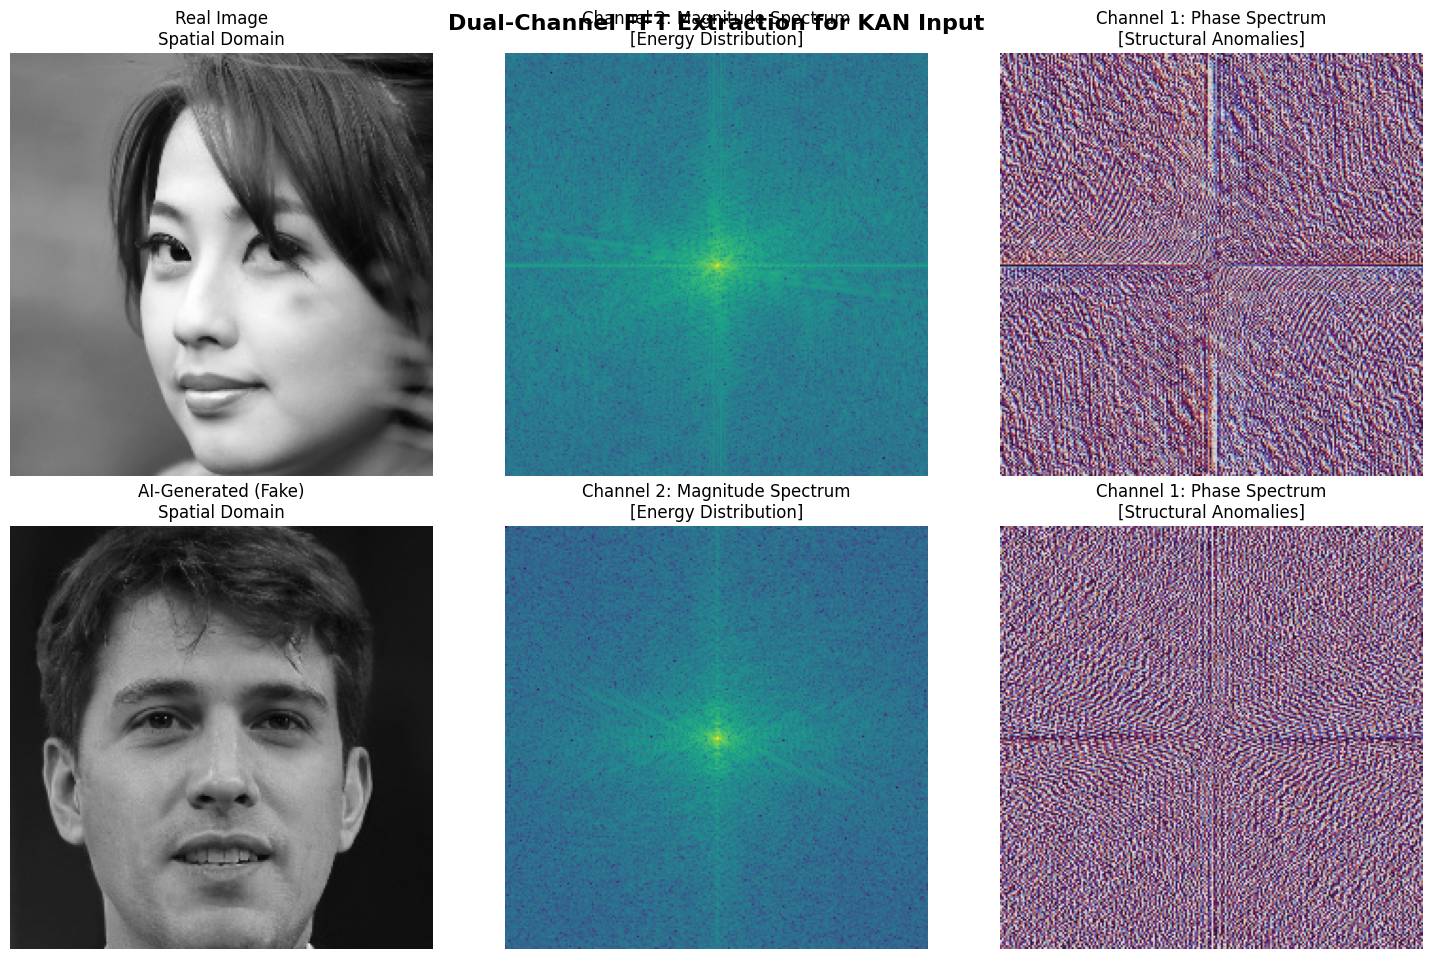

IEEE methodology figure saved → dual_channel_fft_ieee.png ✅


In [5]:
print("\n📐 Generating IEEE methodology figure ...")
print("   → Visualising Spatial → Magnitude → Phase for Real & Fake samples\n")


def plot_fft_transformations(dataset):
    """
    Visualise the dual-channel FFT extraction pipeline for IEEE methodology.
    Pulls one Real and one Fake sample, shows:
      (a) Spatial domain grayscale input
      (b) Log-magnitude spectrum (energy distribution)
      (c) Phase spectrum (structural anomalies)
    """
    real_idx, fake_idx = -1, -1
    for i in range(len(dataset)):
        _, label = dataset[i]
        if label.item() == 0 and real_idx == -1:
            real_idx = i
        if label.item() == 1 and fake_idx == -1:
            fake_idx = i
        if real_idx != -1 and fake_idx != -1:
            break

    indices = [real_idx, fake_idx]
    class_names = ["Real Image", "AI-Generated (Fake)"]

    fig, axes = plt.subplots(len(indices), 3, figsize=(15, 5 * len(indices)))
    fig.suptitle(
        "Dual-Channel FFT Extraction for KAN Input",
        fontsize=16, fontweight="bold", y=0.95,
    )

    for row, idx in enumerate(indices):
        spatial_tensor, _ = dataset[idx]
        spatial_img = spatial_tensor.squeeze(0).numpy()

        fft2 = np.fft.fft2(spatial_img)
        fft_shift = np.fft.fftshift(fft2)

        magnitude = np.log(np.abs(fft_shift) + 1e-8)
        phase = np.angle(fft_shift)

        axes[row, 0].imshow(spatial_img, cmap="gray")
        axes[row, 0].set_title(
            f"{class_names[row]}\nSpatial Domain", fontsize=12
        )
        axes[row, 0].axis("off")

        axes[row, 1].imshow(magnitude, cmap="viridis")
        axes[row, 1].set_title(
            "Channel 2: Magnitude Spectrum\n[Energy Distribution]", fontsize=12
        )
        axes[row, 1].axis("off")

        axes[row, 2].imshow(phase, cmap="twilight")
        axes[row, 2].set_title(
            "Channel 1: Phase Spectrum\n[Structural Anomalies]", fontsize=12
        )
        axes[row, 2].axis("off")

    plt.tight_layout()
    plt.savefig("dual_channel_fft_ieee.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("IEEE methodology figure saved → dual_channel_fft_ieee.png ✅")


plot_fft_transformations(val_ds)

## CELL 5 — Kolmogorov–Arnold Network (KAN) Architecture

In [6]:
#
# A KAN replaces fixed activation functions with *learnable* univariate
# functions on every edge of the network.  We parameterise each edge
# function as a B-spline with trainable coefficients, following the
# approach of Liu et al., 2024 ("KAN: Kolmogorov–Arnold Networks").
#
# For computational tractability on a flattened 224×224 phase spectrum
# (50 176 dims), we first apply a lightweight convolutional feature
# extractor to reduce dimensionality before feeding into KAN layers.
# ═══════════════════════════════════════════════════════════════════════════════


class BSplineActivation(nn.Module):
    """
    Learnable univariate activation via B-spline basis functions.
    Each "edge" in the KAN has its own BSplineActivation.
    """

    def __init__(
        self,
        in_features: int,
        num_knots: int = 8,
        spline_order: int = 3,
    ):
        super().__init__()
        self.in_features = in_features
        self.num_knots = num_knots
        self.spline_order = spline_order
        # Total number of basis functions = num_knots + spline_order - 1
        n_bases = num_knots + spline_order - 1
        # Learnable spline coefficients: one set per input feature
        self.coeff = nn.Parameter(
            torch.randn(in_features, n_bases) * 0.1
        )
        # Fixed uniform knot vector on [-1, 1]
        grid = torch.linspace(-1.0, 1.0, num_knots + 2 * spline_order)
        self.register_buffer("grid", grid)

    def _b_spline_basis(self, x: torch.Tensor) -> torch.Tensor:
        """
        Evaluate B-spline basis functions at points x.
        x: (batch, in_features)
        returns: (batch, in_features, n_bases)
        """
        x = x.unsqueeze(-1)              # (B, D, 1)
        grid = self.grid                  # (K,)
        n_bases = self.num_knots + self.spline_order - 1

        # Order-0 basis (piecewise constant)
        bases = ((x >= grid[:-1]) & (x < grid[1:])).float()  # (B, D, K-1)
        # Trim to n_bases
        bases = bases[..., :n_bases + self.spline_order]

        # Recursion for higher orders
        for k in range(1, self.spline_order + 1):
            n = bases.shape[-1] - 1
            left_num  = x - grid[:n].unsqueeze(0).unsqueeze(0)
            left_den  = (grid[k : k + n] - grid[:n]).unsqueeze(0).unsqueeze(0)
            right_num = grid[k + 1 : k + 1 + n].unsqueeze(0).unsqueeze(0) - x
            right_den = (grid[k + 1 : k + 1 + n] - grid[1 : 1 + n]).unsqueeze(0).unsqueeze(0)

            left  = left_num  / (left_den  + 1e-8) * bases[..., :n]
            right = right_num / (right_den + 1e-8) * bases[..., 1 : n + 1]
            bases = left + right

        return bases[..., :self.coeff.shape[1]]   # (B, D, n_bases)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (batch, in_features)
        returns: (batch, in_features)
        """
        # Clamp input to knot range for numerical stability
        x_clamped = torch.clamp(x, -1.0, 1.0)
        basis = self._b_spline_basis(x_clamped)   # (B, D, n_bases)
        # Weighted sum over basis functions per feature
        out = (basis * self.coeff.unsqueeze(0)).sum(dim=-1)  # (B, D)
        return out


class KANLinear(nn.Module):
    """
    A single KAN layer: learnable activation on each edge, then sum.
    Replaces a standard nn.Linear + activation.
    """

    def __init__(self, in_features: int, out_features: int, num_knots: int = 8):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        # One spline activation per (input, output) pair is expensive;
        # instead we use spline on input features, then a linear map.
        self.spline = BSplineActivation(in_features, num_knots=num_knots)
        self.linear = nn.Linear(in_features, out_features)
        # Residual shortcut (SiLU on raw input, like KAN paper)
        self.base_linear = nn.Linear(in_features, out_features)
        self.base_act = nn.SiLU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Spline path
        spline_out = self.linear(self.spline(x))
        # Base path (residual)
        base_out = self.base_linear(self.base_act(x))
        return spline_out + base_out


class PhaseKAN(nn.Module):
    """
    Dual-Channel PhaseKAN for IEEE Submission.

    Architecture:
      1) Deep Conv stem (5 blocks, stride-1/stride-2 mix):
         2→64 (s2) → 64→128 (s1) → 128→128 (s2) → 128→256 (s1) → 256→256 (s2)
         Preserves spatial detail in stride-1 blocks before reducing.
      2) Global Average Pool → 256-dim vector
      3) High-capacity KAN head: 256 → 128 → 64 → 1
         with 16-knot B-splines for fine-grained activation learning.
    """

    def __init__(
        self,
        in_channels: int = 2,                   # Dual-channel: Phase + Magnitude
        kan_hidden: List[int] = [256, 128, 64],  # Widened capacity
        num_knots: int = 16,                     # Increased B-spline resolution
        dropout: float = 0.3,
    ):
        super().__init__()

        # ── Deep convolutional feature extractor (5 blocks) ──────────────
        self.features = nn.Sequential(
            # Block 1: 2 → 64, stride 2 — initial downsample (224→112)
            nn.Conv2d(in_channels, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.GELU(),
            # Block 2: 64 → 128, stride 1 — preserve spatial detail (112→112)
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.GELU(),
            # Block 3: 128 → 128, stride 2 — downsample (112→56)
            nn.Conv2d(128, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.GELU(),
            # Block 4: 128 → 256, stride 1 — preserve spatial detail (56→56)
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.GELU(),
            # Block 5: 256 → 256, stride 2 — final spatial reduction (56→28)
            nn.Conv2d(256, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.GELU(),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)   # → (B, 256, 1, 1)
        conv_out_dim = 256

        # ── High-capacity KAN classifier head ────────────────────────────
        dims = [conv_out_dim] + kan_hidden + [1]
        layers = []
        for i in range(len(dims) - 1):
            layers.append(KANLinear(dims[i], dims[i + 1], num_knots=num_knots))
            if i < len(dims) - 2:
                layers.append(nn.LayerNorm(dims[i + 1]))
                layers.append(nn.Dropout(dropout))
        self.kan_head = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (B, 2, 224, 224) — dual-channel [phase, magnitude] tensor
        returns: (B, 1) — raw logit (apply sigmoid externally)
        """
        h = self.features(x)       # (B, 256, 28, 28)
        h = self.pool(h)           # (B, 256, 1, 1)
        h = h.flatten(1)           # (B, 256)
        logit = self.kan_head(h)   # (B, 1)
        return logit


# ── instantiate & print summary ─────────────────────────────────────────────
model = PhaseKAN().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {n_params:,}")
print(model)
print("PhaseKAN model ready ✅")

Model parameters: 1,337,154
PhaseKAN(
  (features): Sequential(
    (0): Conv2d(2, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): GELU(approximate='none')
    (6): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): GELU(approximate='none')
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): GELU(approximate='none')
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affin

## CELL 6 — Training & Validation Loop

In [ ]:
# ── hyper-parameters ─────────────────────────────────────────────────────────
NUM_EPOCHS    = 35
LEARNING_RATE = 1e-3                # Increased for deeper architecture
WEIGHT_DECAY  = 1e-3
GRAD_CLIP     = 1.0
PATIENCE      = 10                  # Increased — give the model runway to learn

USE_AMP = DEVICE.type == "cuda"
AMP_DTYPE = torch.float16

# Channels-last can improve Conv throughput on T4
if DEVICE.type == "cuda":
    model = model.to(memory_format=torch.channels_last)

# Optional graph compile (safe fallback if unavailable)
if DEVICE.type == "cuda" and hasattr(torch, "compile"):
    try:
        model = torch.compile(model, mode="reduce-overhead")
        print("torch.compile enabled ✅")
    except Exception as e:
        print(f"torch.compile skipped: {e}")

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(
    model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-6
)
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

# ── training utilities ───────────────────────────────────────────────────────

def train_one_epoch(model, loader, criterion, optimizer, device, scaler, grad_clip=1.0):
    model.train()
    running_loss = 0.0
    n_correct = 0
    n_total   = 0
    batch_times = []

    for spatial_batch, labels in tqdm(loader, desc="  train", leave=False):
        t_batch = time.time()

        # Move raw spatial tensors to GPU
        spatial_batch = spatial_batch.to(device, non_blocking=True)
        if device.type == "cuda":
            spatial_batch = spatial_batch.contiguous(memory_format=torch.channels_last)
        labels = labels.to(device, non_blocking=True).unsqueeze(1)

        optimizer.zero_grad(set_to_none=True)

        # Keep FFT in fp32 for numerical stability, then AMP model forward/backward
        phase_batch = extract_phase_spectrum_gpu(spatial_batch)

        amp_ctx = torch.autocast(device_type="cuda", dtype=AMP_DTYPE) if USE_AMP else nullcontext()
        with amp_ctx:
            logits = model(phase_batch)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * spatial_batch.size(0)
        preds = (torch.sigmoid(logits) >= 0.5).float()
        n_correct += (preds == labels).sum().item()
        n_total   += labels.size(0)
        batch_times.append(time.time() - t_batch)

    epoch_loss = running_loss / n_total
    epoch_acc  = n_correct / n_total
    avg_batch_time = max(np.mean(batch_times), 1e-6)
    it_per_s = 1.0 / avg_batch_time
    return epoch_loss, epoch_acc, it_per_s


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_probs  = []
    all_labels = []

    for spatial_batch, labels in tqdm(loader, desc="  eval ", leave=False):
        # Move raw spatial tensors to GPU
        spatial_batch = spatial_batch.to(device, non_blocking=True)
        if device.type == "cuda":
            spatial_batch = spatial_batch.contiguous(memory_format=torch.channels_last)
        labels = labels.to(device, non_blocking=True).unsqueeze(1)

        phase_batch = extract_phase_spectrum_gpu(spatial_batch)

        amp_ctx = torch.autocast(device_type="cuda", dtype=AMP_DTYPE) if USE_AMP else nullcontext()
        with amp_ctx:
            logits = model(phase_batch)
            loss = criterion(logits, labels)

        running_loss += loss.item() * spatial_batch.size(0)
        probs = torch.sigmoid(logits).cpu()
        all_probs.append(probs)
        all_labels.append(labels.cpu())

    all_probs  = torch.cat(all_probs).numpy().flatten()
    all_labels = torch.cat(all_labels).numpy().flatten()
    n_total    = len(all_labels)
    epoch_loss = running_loss / n_total
    preds      = (all_probs >= 0.5).astype(float)
    epoch_acc  = accuracy_score(all_labels, preds)
    return epoch_loss, epoch_acc, all_probs, all_labels


# ── training loop ────────────────────────────────────────────────────────────
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "train_it_s": []}
best_val_loss = float("inf")
patience_counter = 0
best_model_state = None

print(f"\n{'='*60}")
print(f" Training — {NUM_EPOCHS} epochs, lr={LEARNING_RATE}, wd={WEIGHT_DECAY}")
print(f" AMP: {USE_AMP} | Batch size: {BATCH_SIZE} | Workers: {NUM_WORKERS}")
print(f"{'='*60}\n")

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc, train_it_s = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE, scaler, GRAD_CLIP
    )
    val_loss, val_acc, _, _ = evaluate(
        model, val_loader, criterion, DEVICE
    )
    scheduler.step()

    dt = time.time() - t0
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["train_it_s"].append(train_it_s)

    star = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        star = " ★"
    else:
        patience_counter += 1

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} │ "
        f"train loss {train_loss:.4f} acc {train_acc:.4f} ({train_it_s:.2f} it/s) │ "
        f"val loss {val_loss:.4f} acc {val_acc:.4f} │ "
        f"{dt:.1f}s{star}"
    )

    if patience_counter >= PATIENCE:
        print(f"\n⏹  Early stopping at epoch {epoch} (patience={PATIENCE})")
        break

# Restore best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    model.to(DEVICE)
print("\nTraining complete ✅  (best model restored)")


 Training — 35 epochs, lr=0.001, wd=0.001



  train:   0%|          | 0/546 [00:00<?, ?it/s]

  eval :   0%|          | 0/118 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f40789f47c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f40789f47c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 01/35 │ train loss 0.6605 acc 0.5924 │ val loss 0.6222 acc 0.6495 │ 211.2s ★


...

Epoch 21/35 │ train loss 0.4952 acc 0.7521 │ val loss 0.4743 acc 0.7664 │ 222.5s ★


  train:   0%|          | 0/546 [00:00<?, ?it/s]

  eval :   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 22/35 │ train loss 0.4906 acc 0.7534 │ val loss 0.4675 acc 0.7755 │ 222.1s ★


  train:   0%|          | 0/546 [00:00<?, ?it/s]

## CELL 7 — Test-Set Evaluation & IEEE-Standard Metrics

In [ ]:
test_loss, test_acc, test_probs, test_labels = evaluate(
    model, test_loader, criterion, DEVICE
)
test_preds = (test_probs >= 0.5).astype(float)

# ── compute all metrics ──────────────────────────────────────────────────────
precision = precision_score(test_labels, test_preds, zero_division=0)
recall    = recall_score(test_labels, test_preds, zero_division=0)
f1        = f1_score(test_labels, test_preds, zero_division=0)
roc_auc   = roc_auc_score(test_labels, test_probs)

print(f"\n{'='*60}")
print(f" Test-Set Results")
print(f"{'='*60}")
print(f"  Loss      : {test_loss:.4f}")
print(f"  Accuracy  : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print(f"  ROC-AUC   : {roc_auc:.4f}")
print(f"{'='*60}\n")

print("Classification Report:")
print(classification_report(
    test_labels, test_preds,
    target_names=["Real", "Fake"], digits=4
))

## CELL 8 — Visualisation: ROC Curve, Confusion Matrix, Learning Curves

In [ ]:
print("\n📊 Generating visualisations ...")
print("   → (a) ROC Curve")
print("   → (b) Confusion Matrix")
print("   → (c) Learning Curves\n")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── (a) ROC Curve ────────────────────────────────────────────────────────────
print("  [1/3] Plotting ROC Curve ...")
fpr, tpr, _ = roc_curve(test_labels, test_probs)
axes[0].plot(fpr, tpr, color="royalblue", lw=2,
             label=f"KAN (AUC = {roc_auc:.4f})")
axes[0].plot([0, 1], [0, 1], "--", color="grey", lw=1)
axes[0].set_xlabel("False Positive Rate", fontsize=12)
axes[0].set_ylabel("True Positive Rate", fontsize=12)
axes[0].set_title("ROC Curve", fontsize=14, fontweight="bold")
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)
print("        ROC Curve done ✅")

# ── (b) Confusion Matrix ────────────────────────────────────────────────────
print("  [2/3] Plotting Confusion Matrix ...")
cm = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Real", "Fake"])
disp.plot(ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title("Confusion Matrix", fontsize=14, fontweight="bold")
print("        Confusion Matrix done ✅")

# ── (c) Learning Curves ─────────────────────────────────────────────────────
print("  [3/3] Plotting Learning Curves ...")
epochs_range = list(range(1, len(history["train_loss"]) + 1))
axes[2].plot(epochs_range, history["train_loss"], label="Train Loss", lw=2)
axes[2].plot(epochs_range, history["val_loss"], label="Val Loss", lw=2)
ax2 = axes[2].twinx()
ax2.plot(epochs_range, history["train_acc"], "--", label="Train Acc", lw=1.5, color="green")
ax2.plot(epochs_range, history["val_acc"], "--", label="Val Acc", lw=1.5, color="red")
axes[2].set_xlabel("Epoch", fontsize=12)
axes[2].set_ylabel("Loss", fontsize=12)
ax2.set_ylabel("Accuracy", fontsize=12)
axes[2].set_title("Learning Curves", fontsize=14, fontweight="bold")
lines1, labels1 = axes[2].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[2].legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc="center right")
axes[2].grid(alpha=0.3)
print("        Learning Curves done ✅")

# ── Save to disk ─────────────────────────────────────────────────────────────
plt.tight_layout()
results_path = "kan_deepfake_results.png"
plt.savefig(results_path, dpi=150, bbox_inches="tight")
print(f"\n💾 Results figure saved → {results_path}")

# ── Display inline (Colab / Jupyter) ─────────────────────────────────────────
print("🖼️  Displaying results inline ...")
plt.show()
print("Visualisations complete ✅")

## CELL 9 — Save Model & Training Summary

In [ ]:
SAVE_DIR = Path("runs/kan_deepfake")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Save model checkpoint
ckpt_path = SAVE_DIR / "best_phase_kan.pt"
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "epoch": len(history["train_loss"]),
    "best_val_loss": best_val_loss,
    "config": {
        "crop_size": CROP_SIZE,
        "batch_size": BATCH_SIZE,
        "lr": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "grad_clip": GRAD_CLIP,
        "seed": SEED,
    },
}, ckpt_path)
print(f"Checkpoint saved → {ckpt_path}")

# Save training summary JSON (for paper appendix)
summary = {
    "dataset": "DeepDetect-2025",
    "model": "PhaseKAN (Conv stem + KAN classifier)",
    "parameters": n_params,
    "crop_size": CROP_SIZE,
    "train_samples": len(train_ds),
    "val_samples": len(val_ds),
    "test_samples": len(test_ds),
    "epochs_trained": len(history["train_loss"]),
    "best_val_loss": best_val_loss,
    "test_metrics": {
        "loss": round(test_loss, 4),
        "accuracy": round(test_acc, 4),
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1_score": round(f1, 4),
        "roc_auc": round(roc_auc, 4),
    },
    "history": history,
}
summary_path = SAVE_DIR / "training_summary.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)
print(f"Summary saved  → {summary_path}")
print("\n🏁 Pipeline complete.")